# Notebook 01 — Data Audit & Cleaning

**Project:** Cat vs Dog Image Classification: A Comparative Deep Learning Study

**Goal of this notebook:** understand the dataset, find data-quality problems, and produce a clean
file list (manifest) for Notebook 02. No modeling, no TensorFlow, no augmentation, no train/test
split here — those come later.


## 1. Project Setup

### What we are checking
Basic imports and settings we'll reuse for the rest of the notebook.


In [1]:
import random
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import warnings
warnings.filterwarnings(
    "ignore", message="Truncated File Read", category=UserWarning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_ROOT = Path("PetImages")
CLASS_FOLDERS = {"Cat": 0, "Dog": 1}

MANIFEST_PATH = DATASET_ROOT.parent / "clean_manifest.csv"

## 2. Dataset Structure & Class Counts

### What we are checking
That the dataset folders exist, and how many files are actually in each class (not assumed —
counted). The original dataset is reported to have 12,499 Cat and 12,499 Dog images, but we
calculate the real numbers ourselves.


In [2]:
assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"
for class_name in CLASS_FOLDERS:
    assert (DATASET_ROOT / class_name).exists(), f"Missing folder: {class_name}"

class_counts = {
    class_name: sum(path.is_file() for path in (DATASET_ROOT / class_name).iterdir())
    for class_name in CLASS_FOLDERS
}
class_counts["Total"] = sum(class_counts.values())

pd.Series(class_counts, name="Count").to_frame()

,Count
Cat,12499
Dog,12499
Total,24998


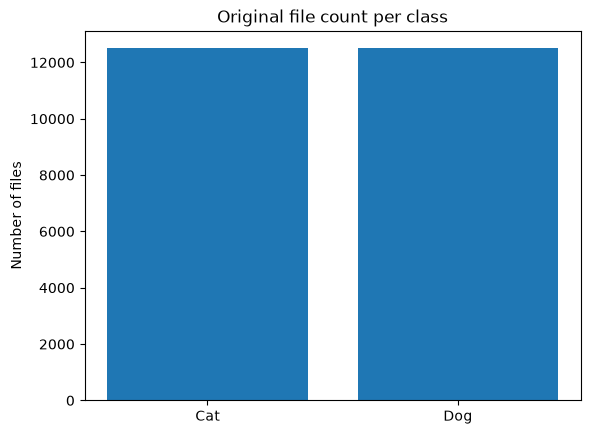

In [3]:
plt.bar(list(CLASS_FOLDERS.keys()), [class_counts[c] for c in CLASS_FOLDERS])
plt.title("Original file count per class")
plt.ylabel("Number of files")
plt.show()

### What we learned
- Actual file counts per class (see table above), not assumed from the dataset description.
- This is our real starting point for everything that follows.


## 3. Image Inspection

### What we are checking
We inspect every image one at a time and record its metadata (never loading the whole dataset
into memory): size, format, color mode, whether it's readable, and a content hash
(used later for duplicate detection — an MD5 hash is just a short fingerprint: two files with the
exact same content produce the exact same hash).

We do this in **one pass over the dataset** and store the results in a single DataFrame, so every
later section just filters this table instead of re-reading the files.

Note: for each image, `inspect_image()` below may still open/read the file more than once
internally (once to verify it, once to read its size/mode, once to hash it) — the "one pass" refers
to looping through the dataset once, not to a single physical file read.


In [4]:
def compute_file_hash(path):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


def inspect_image(path):
    info = {"is_corrupt": False, "width": None, "height": None, "mode": None, "file_hash": None}
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            info["width"], info["height"] = img.size
            info["mode"] = img.mode
        info["file_hash"] = compute_file_hash(path)
    except (UnidentifiedImageError, OSError, SyntaxError, ValueError):
        info["is_corrupt"] = True
    return info


In [5]:
rows = []
for class_name, label in CLASS_FOLDERS.items():
    for path in sorted((DATASET_ROOT / class_name).iterdir()):
        if not path.is_file():
            continue
        row = {
            "filepath": str(path),
            "class_name": class_name,
            "label": label,
            "extension": path.suffix.lower(),
            "filesize_bytes": path.stat().st_size,
        }
        row.update(inspect_image(path))
        row["remove_reason"] = None
        rows.append(row)

df = pd.DataFrame(rows)
print(f"Inspected {len(df)} files")
df.head()


Inspected 24998 files


,filepath,class_name,label,extension,filesize_bytes,is_corrupt,width,height,mode,file_hash,remove_reason
0,PetImages\Cat\0.jpg,Cat,0,.jpg,12213,False,500,375,RGB,ac324e8cd203e74c35a97bebb1678679,None
1,PetImages\Cat\1.jpg,Cat,0,.jpg,16868,False,300,281,RGB,4672f1c00d951951e0507a2c8670b6e3,None
2,PetImages\Cat\10.jpg,Cat,0,.jpg,35381,False,489,500,RGB,af3d6504aa68e15dba30580ad6f843a9,None
3,PetImages\Cat\100.jpg,Cat,0,.jpg,30725,False,403,500,RGB,9507efc7e9cc2388e45d372d5d353e2b,None
4,PetImages\Cat\1000.jpg,Cat,0,.jpg,26344,False,150,150,RGB,dd7e3f0956eeb2ebeab91c65bb4547f1,None


### What we learned
- One metadata table (`df`) now holds everything we need: size, mode, hash, corruption status.
- Every later section reuses this table — no re-scanning the folders.


## 4. Corrupted Images

### What we are checking
Which files failed the readability check in Section 3. These can't be opened as valid images at
all, so a model would crash on them — we flag them, we don't delete them.


In [6]:
corrupt_df = df[df["is_corrupt"]]
print(f"Corrupt files found: {len(corrupt_df)}")
corrupt_df[["filepath", "class_name"]]


Corrupt files found: 0


,filepath,class_name


In [7]:
df.loc[df["is_corrupt"], "remove_reason"] = "corrupt"


### What we learned
- Number of unreadable files, and which class they belong to.
- They're tagged `corrupt` in `remove_reason` — nothing has been deleted yet.


## 5. Image Size & Format Analysis

### What we are checking
Image dimensions (to understand how much resizing Notebook 02 will need to do), whether any
images are suspiciously small, and what color modes/formats exist (e.g. RGB vs grayscale vs RGBA —
these will need consistent handling later, but we don't convert anything here).


             width      height
min       4.000000    4.000000
max     500.000000  500.000000
median  448.000000  375.000000
mean    404.447196  360.989239


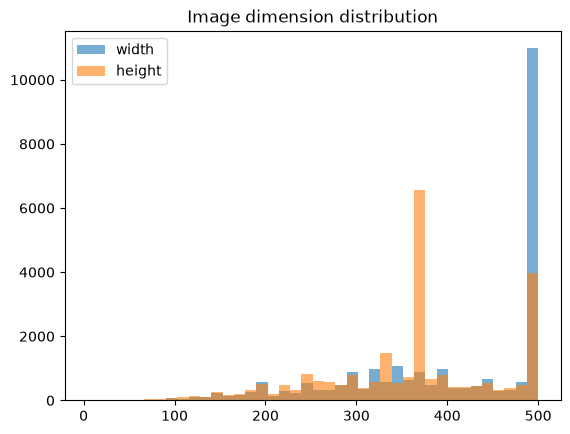

In [8]:
valid_df = df[df["remove_reason"].isna()].copy()

print(valid_df[["width", "height"]].agg(["min", "max", "median", "mean"]))

plt.hist(valid_df["width"], bins=40, alpha=0.6, label="width")
plt.hist(valid_df["height"], bins=40, alpha=0.6, label="height")
plt.legend()
plt.title("Image dimension distribution")
plt.show()

**Very small images:** we look at the smallest images before deciding anything. `32px` below
is only a starting point to inspect — not a scientifically fixed rule, and it does not
automatically remove anything. If the smallest images below are still clearly recognizable
cats/dogs, they should stay in the dataset.


      class_name  width  height
7694         Cat      4       4
8505         Cat     60      33
18741        Dog    196      33
7540         Cat     60      36
13889        Dog    100      37
11580        Cat    145      39


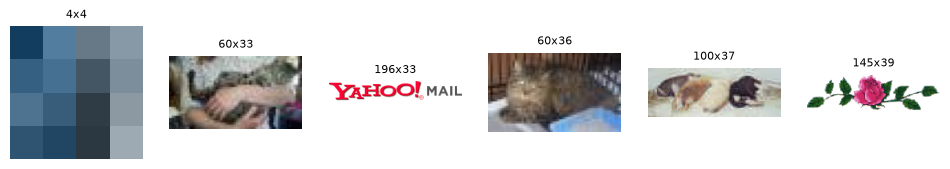

In [9]:
valid_df["min_side"] = valid_df[["width", "height"]].min(axis=1)
smallest = valid_df.nsmallest(6, "min_side")
print(smallest[["class_name", "width", "height"]])

fig, axes = plt.subplots(1, len(smallest), figsize=(12, 2.5))
for ax, (_, row) in zip(axes, smallest.iterrows()):
    ax.imshow(Image.open(row["filepath"]))
    ax.set_title(f'{row["width"]}x{row["height"]}', fontsize=8)
    ax.axis("off")
plt.show()


In [10]:
MIN_SIDE_CANDIDATE = 32  # inspection threshold only  not applied automatically

too_small = valid_df[valid_df["min_side"] < MIN_SIDE_CANDIDATE]
print(f"Images below {MIN_SIDE_CANDIDATE}px: {len(too_small)}")
print(too_small[["class_name", "width", "height"]])

# Not automatically excluded — this is for review only. If any of these are genuinely
# unusable after looking at them, exclude them manually by editing remove_reason yourself.

Images below 32px: 1
     class_name  width  height
7694        Cat      4       4


In [11]:
mode_counts = df.loc[df["remove_reason"].isna(), "mode"].value_counts()
print(mode_counts)

ext_counts = df["extension"].value_counts()
print(ext_counts)

mode
RGB     24931
P          57
L           5
CMYK        3
RGBA        2
Name: count, dtype: int64
extension
.jpg    24998
Name: count, dtype: int64


### What we learned
- Typical image size range, so we know how much resizing to expect in Notebook 02.
- How many images fall below the inspection threshold, and whether they're genuinely
  low-quality or just small but valid (none are auto-excluded here).
- What color modes/extensions exist — Notebook 02 will need to handle any non-RGB images
  consistently, but we don't convert them here.


## 6. Duplicate Detection

### What we are checking
Files with the exact same content (same hash) are exact duplicates. We split these into two cases:

- **Within-class** (e.g. two Cat files, same content) — safe to deduplicate automatically.
- **Cross-class** (e.g. a Cat file and a Dog file, same content) — this is a labeling conflict.
  The hash proves the files are identical, but it doesn't tell us which label is correct, so these
  need manual review, not an automatic decision.


In [12]:
valid_df = df[df["remove_reason"].isna()].copy()

dup_hashes = valid_df["file_hash"].value_counts()
dup_hashes = dup_hashes[dup_hashes > 1].index

within_class_hashes = []
cross_class_hashes = []

for h, group in valid_df[valid_df["file_hash"].isin(dup_hashes)].groupby("file_hash"):
    if group["class_name"].nunique() == 1:
        within_class_hashes.append(h)
    else:
        cross_class_hashes.append(h)

print(f"Within-class duplicate groups: {len(within_class_hashes)}")
print(f"Cross-class duplicate groups:  {len(cross_class_hashes)}")


Within-class duplicate groups: 26
Cross-class duplicate groups:  2


### What we learned
- How many exact duplicate groups exist, split by whether they're safe to auto-clean or need a
  human decision.


## 7. Cleaning Decisions

### What we are checking
Applying the two duplicate rules from Section 6, and reviewing cross-class duplicates by hand.

**Within-class:** keep the first file (alphabetically), mark the rest `duplicate_within_class`.

**Cross-class:** print them for manual review, mark them `duplicate_cross_class_review`, and keep
them **out of the final manifest**. If none exist, we simply report that.


In [13]:
for h in within_class_hashes:
    group = valid_df[valid_df["file_hash"] == h].sort_values("filepath")
    duplicates = group.iloc[1:]
    df.loc[duplicates.index, "remove_reason"] = "duplicate_within_class"

print("Within-class duplicates removed:", (df["remove_reason"] == "duplicate_within_class").sum())


Within-class duplicates removed: 26


In [14]:
if len(cross_class_hashes) == 0:
    print("No cross-class duplicates found.")
else:
    review_df = valid_df[valid_df["file_hash"].isin(cross_class_hashes)][
        ["file_hash", "filepath", "class_name"]
    ].sort_values("file_hash")
    print("Cross-class duplicates — review manually, do not auto-resolve:")
    print(review_df[['file_hash','class_name']])

    df.loc[review_df.index, "remove_reason"] = "duplicate_cross_class_review"



Cross-class duplicates — review manually, do not auto-resolve:
                              file_hash class_name
10785  390077ecfeed69cd2ad3adc9cf0737ae        Cat
23595  390077ecfeed69cd2ad3adc9cf0737ae        Dog
1742   e7ad017a649710c27732e163dfac82e0        Cat
12949  e7ad017a649710c27732e163dfac82e0        Dog
13387  e7ad017a649710c27732e163dfac82e0        Dog
17085  e7ad017a649710c27732e163dfac82e0        Dog


### What we learned
- Within-class duplicates are cleaned automatically (label wasn't in question).
- Any cross-class duplicates are listed for manual review and excluded from the manifest until
  someone decides which label is correct.


## 8. Final Validation

### What we are checking
A few simple, direct checks on the files we're about to put in the manifest — no complicated
framework, just plain assertions.


In [15]:
usable_df = df[df["remove_reason"].isna()].copy()

assert usable_df["filepath"].apply(lambda p: Path(p).exists()).all(), "Some manifest paths are missing"
assert usable_df["filepath"].is_unique, "Duplicate filepaths in manifest"
assert usable_df["class_name"].isin(["Cat", "Dog"]).all(), "Unexpected class name found"
assert usable_df["label"].isin([0, 1]).all(), "Unexpected label found"
assert (usable_df.loc[usable_df["class_name"] == "Cat", "label"] == 0).all(), "Cat must map to 0"
assert (usable_df.loc[usable_df["class_name"] == "Dog", "label"] == 1).all(), "Dog must map to 1"
assert (usable_df["is_corrupt"] == False).all(), "Corrupt file leaked into manifest"
assert not usable_df["filepath"].isin(
    df.loc[df["remove_reason"] == "duplicate_cross_class_review", "filepath"]
).any(), "Unresolved cross-class duplicate leaked into manifest"
assert usable_df["class_name"].nunique() == 2, "One class has zero usable images"

print("All checks passed")
print("Usable images:", len(usable_df))


All checks passed
Usable images: 24966


### What we learned
- The manifest we're about to save contains no corrupt files, no duplicate paths, no unresolved
  cross-class conflicts, and correct Cat/Dog → 0/1 labels.


## 9. Save Manifest

### What we are checking
Writing the approved file list to a CSV so Notebook 02 can load it directly, without re-running
this audit.


In [16]:
manifest = usable_df[["filepath", "class_name", "label"]].reset_index(drop=True)
manifest.to_csv(MANIFEST_PATH, index=False)

print("Saved to:", # MANIFEST_PATH
      )
print("Rows:", len(manifest))
manifest.head()

Saved to:
Rows: 24966


,filepath,class_name,label
0,PetImages\Cat\0.jpg,Cat,0
1,PetImages\Cat\1.jpg,Cat,0
2,PetImages\Cat\10.jpg,Cat,0
3,PetImages\Cat\100.jpg,Cat,0
4,PetImages\Cat\1000.jpg,Cat,0


In [17]:
# The original dataset is never modified by this notebook. Cleaning decisions are only
# recorded in `remove_reason` and reflected in clean_manifest.csv — no files are moved.


### What we learned
- `clean_manifest.csv` now exists and is the only thing Notebook 02 needs to read.
- The original dataset folders were never modified — flagged files simply aren't included
  in the manifest.


## 10. Image Format Normalization

### What we are checking
The dataset is not uniformly JPEG/RGB. Inspecting the approved images with Pillow shows a mix of
formats and color modes (JPEG/RGB, but also BMP, GIF, PNG, PSD, grayscale, CMYK, palette mode,
etc.). TensorFlow's `tf.image.decode_jpeg` only understands JPEG bytes, and `tf.image.decode_image`
still fails on some modes (e.g. palette images with 2 channels), so Notebook 02/03 crashed when
loading these files directly.

### Why we do it here, not in Notebook 02
Rather than making the `tf.data` pipeline dynamically handle every format (which pulls Pillow into
the training loop via `tf.py_function` and slows things down), we normalize once, here, into a
separate folder of plain RGB JPEGs. Notebook 02 can then use a simple, fast
`tf.image.decode_jpeg(..., channels=3)` on every file with no special cases.

**The original `PetImages` folder is never modified.** We write normalized copies into a new
folder, `PetImages_RGB`, with the same `Cat` / `Dog` structure.


In [18]:
NORMALIZED_ROOT = DATASET_ROOT.parent / "PetImages_RGB"

for class_name in CLASS_FOLDERS:
    (NORMALIZED_ROOT / class_name).mkdir(parents=True, exist_ok=True)

print("Normalized dataset root:", NORMALIZED_ROOT)


Normalized dataset root: PetImages_RGB


**Handling filename collisions:** we reuse the original filename as the new JPEG's base name,
but two different original files could share a stem (e.g. `cat_15.jpg` and `cat_15.bmp`). We track
every destination path we've already used and rename on collision, so nothing is silently
overwritten.

**Handling conversion problems honestly:** a small number of files may raise a warning while being
read (e.g. `UserWarning: Truncated File Read`) without raising an exception. We don't ignore that —
we still save the file, then reopen and `verify()` the saved copy to confirm it's actually valid,
and we record the warning in the report either way.


In [19]:
import warnings
from PIL import ImageFile


def make_unique(path: Path, used_paths: set) -> Path:
    """Return a path guaranteed not to collide with anything already in used_paths"""
    candidate = path
    counter = 1
    while candidate in used_paths:
        candidate = path.with_name(f"{path.stem}_{counter}{path.suffix}")
        counter += 1
    used_paths.add(candidate)
    return candidate


def normalize_image(src_path: Path, dest_path: Path) -> dict:
    result = {
        "original_format": None,
        "original_mode": None,
        "conversion_status": "failed",
        "error_message": None,
    }

    previous_setting = ImageFile.LOAD_TRUNCATED_IMAGES
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            with Image.open(src_path) as img:
                result["original_format"] = img.format
                result["original_mode"] = img.mode
                rgb_img = img.convert("RGB")
                rgb_img.save(dest_path, format="JPEG", quality=95)

        if caught:
            # A warning was raised (e.g. a truncated file that Pillow recovered from).
            # Confirm the saved copy is genuinely valid before calling this a success.
            with Image.open(dest_path) as check_img:
                check_img.verify()
            result["conversion_status"] = "success_with_warning"
            result["error_message"] = "; ".join(str(w.message) for w in caught)
        else:
            result["conversion_status"] = "success"

    except Exception as e:
        result["conversion_status"] = "failed"
        result["error_message"] = str(e)
    finally:
        ImageFile.LOAD_TRUNCATED_IMAGES = previous_setting

    return result


In [20]:
conversion_rows = []

for _, row in manifest.iterrows():
    src_path = Path(row["filepath"])

    dest_path = NORMALIZED_ROOT / row["class_name"] / f"{src_path.stem}.jpg"
    dest_path.parent.mkdir(parents=True, exist_ok=True)

    result = normalize_image(src_path, dest_path)

    conversion_rows.append({
        "filepath": str(src_path),
        "normalized_filepath": str(dest_path),
        "class_name": row["class_name"],
        "label": row["label"],
        **result
    })

conversion_report = pd.DataFrame(conversion_rows)

print(f"Files processed: {len(conversion_report):,}")
print(conversion_report["conversion_status"].value_counts())

Files processed: 24,966
conversion_status
success                 24965
success_with_warning        1
Name: count, dtype: int64


### What we learned
- How many files converted cleanly, converted with a warning (but were verified valid), or failed.
- If any file failed, we stop before touching the manifest — see the next cell.


In [21]:
failed = conversion_report[conversion_report["conversion_status"] == "failed"]

if len(failed) > 0:
    print(f"CONVERSION FAILED for {len(failed)} file(s) -- manifest will NOT be updated:")
    print(failed[["filepath", "original_format", "original_mode", "error_message"]].to_string(index=False))
    raise AssertionError(
        "Stopping: one or more files failed conversion. Review the report above, decide how to "
        "handle these files, and only then re-run normalization."
    )

with_warning = conversion_report[conversion_report["conversion_status"] == "success_with_warning"]
if len(with_warning) > 0:
    print(f"{len(with_warning)} file(s) converted successfully but raised a warning while reading:")
    print(with_warning[["filepath", "original_format", "error_message"]].to_string(index=False))
else:
    print("No conversion warnings.")

print("All files converted successfully -- safe to update the manifest.")


1 file(s) converted successfully but raised a warning while reading:
              filepath original_format       error_message
PetImages\Dog\9041.jpg            JPEG Truncated File Read
All files converted successfully -- safe to update the manifest.


In [22]:
# Save the conversion report separately -- this is a diagnostic artifact, not the manifest.
REPORT_PATH = DATASET_ROOT.parent / "normalization_report.csv"
conversion_report.to_csv(REPORT_PATH, index=False)
print("Conversion report saved to:", REPORT_PATH)

# Point the manifest at the normalized copies and overwrite the official clean_manifest.csv.
manifest["filepath"] = conversion_report["normalized_filepath"].values
manifest.to_csv(MANIFEST_PATH, index=False)

print("Manifest updated to point to PetImages_RGB and re-saved to:", MANIFEST_PATH)
manifest.head()


Conversion report saved to: normalization_report.csv
Manifest updated to point to PetImages_RGB and re-saved to: clean_manifest.csv


,filepath,class_name,label
0,PetImages_RGB\Cat\0.jpg,Cat,0
1,PetImages_RGB\Cat\1.jpg,Cat,0
2,PetImages_RGB\Cat\10.jpg,Cat,0
3,PetImages_RGB\Cat\100.jpg,Cat,0
4,PetImages_RGB\Cat\1000.jpg,Cat,0


### Validate the normalized dataset

**What we are checking:** that normalization didn't change *which* images are in the dataset or
what they're labeled, that every normalized file genuinely is a readable RGB JPEG, that TensorFlow
can actually decode a sample of them, and that the original dataset is untouched.


In [23]:
# Row count and class counts must match the pre-normalization approved dataset exactly
assert len(manifest) == len(usable_df), "Manifest row count changed during normalization"
assert (manifest["class_name"] == "Cat").sum() == (usable_df["class_name"] == "Cat").sum()
assert (manifest["class_name"] == "Dog").sum() == (usable_df["class_name"] == "Dog").sum()

print("Manifest rows:", len(manifest))
print(manifest["class_name"].value_counts())

# Every manifest filepath must exist
missing = manifest["filepath"].apply(lambda p: not Path(p).exists())
assert missing.sum() == 0, f"{missing.sum()} normalized file(s) referenced in the manifest are missing"
print("Missing files:", missing.sum())


Manifest rows: 24966
class_name
Dog    12486
Cat    12480
Name: count, dtype: int64
Missing files: 0


In [24]:
# Every normalized file must be a valid, readable JPEG in RGB mode
bad_files = []
for path in manifest["filepath"]:
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            if img.format != "JPEG" or img.mode != "RGB":
                bad_files.append((path, img.format, img.mode))
    except Exception as e:
        bad_files.append((path, "ERROR", str(e)))

assert len(bad_files) == 0, f"{len(bad_files)} normalized file(s) failed the JPEG/RGB check"
print(f"JPEG: {len(manifest) - len(bad_files)} / {len(manifest)}")
print(f"RGB:  {len(manifest) - len(bad_files)} / {len(manifest)}")


JPEG: 24966 / 24966
RGB:  24966 / 24966


In [25]:
# TensorFlow must actually be able to decode a sample of the normalized files
import tensorflow as tf

sample_paths = manifest["filepath"].sample(n=min(20, len(manifest)), random_state=SEED)
tf_failures = []
for path in sample_paths:
    try:
        raw = tf.io.read_file(path)
        tf.image.decode_jpeg(raw, channels=3)
    except Exception as e:
        tf_failures.append((path, str(e)))

assert len(tf_failures) == 0, f"tf.image.decode_jpeg failed on {len(tf_failures)} sampled file(s)"
print(f"tf.image.decode_jpeg succeeded on all {len(sample_paths)} sampled normalized images.")


tf.image.decode_jpeg succeeded on all 20 sampled normalized images.


In [26]:
# The original dataset must remain exactly as it was in Section 2
current_original_counts = {
    class_name: sum(path.is_file() for path in (DATASET_ROOT / class_name).iterdir())
    for class_name in CLASS_FOLDERS
}
original_counts_at_start = {k: v for k, v in class_counts.items() if k in CLASS_FOLDERS}

assert current_original_counts == original_counts_at_start, "Original dataset changed during this notebook!"
print("Original PetImages file counts unchanged:", current_original_counts)


Original PetImages file counts unchanged: {'Cat': 12499, 'Dog': 12499}


### What we learned
- The normalized dataset has exactly the same rows, classes, and labels as the approved manifest —
  normalization only changed *where* and *how* each file is stored, not which images are included.
- Every normalized file is a genuine RGB JPEG that both Pillow and TensorFlow can read.
- The original `PetImages` folder was never touched.


## 11. Summary


In [27]:
summary = {
    "Original files": len(df),
    "Usable files": len(usable_df),
    "Excluded files": len(df) - len(usable_df),
    "Cat (usable)": (usable_df["class_name"] == "Cat").sum(),
    "Dog (usable)": (usable_df["class_name"] == "Dog").sum(),
    "Corrupted": (df["remove_reason"] == "corrupt").sum(),
    "Within-class duplicates": (df["remove_reason"] == "duplicate_within_class").sum(),
    "Cross-class duplicates (needs review)": (df["remove_reason"] == "duplicate_cross_class_review").sum(),
}
pd.Series(summary, name="Count").to_frame()


,Count
Original files,24998
Usable files,24966
Excluded files,32
Cat (usable),12480
Dog (usable),12486
Corrupted,0
Within-class duplicates,26
Cross-class duplicates (needs review),6


**Conclusion:** the dataset was audited for corruption, unusual sizes/modes, and exact
duplicates. Corrupt files were excluded, within-class duplicates were deduplicated
automatically, and cross-class duplicates were flagged for manual review rather than resolved
automatically. Very-small images were inspected but not automatically excluded. Every approved
image was then normalized to RGB JPEG in `PetImages_RGB` (the original dataset was left
untouched), and the normalized dataset was independently validated. `clean_manifest.csv` now
points to the normalized files and is ready for Notebook 02.
